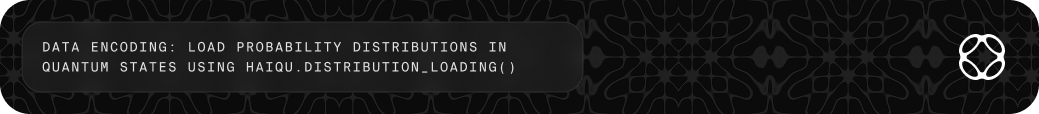

This notebook demonstrates how to use `haiqu.distribution_loading()` to efficiently prepare a probability distribution in a quantum state. 

<!-- Made it more direct. Rouded off and highlighted only the gains. -->

- Loading a log-normal distribution on 12 qubits traditionally requires 4083 CNOT gates and a two-qubit gate depth of 4083.
- With Haiqu, the same distribution is prepared using only 21 CNOT gates **(194.4x improvement)** and a two-qubit gate depth of 11 **(371.2x improvement)**.

### `haiqu.distribution_loading()`

- **What does it do?** Distribution loading prepares a quantum state whose measurement statistics match a desired probability density function.
- **How do I use it?** Pass a [scipy](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions) distribution name, its parameters and intervals, and size of the quantum register to `haiqu.distribution_loading()`. This will create a data loading job. The results can be retrieved with `job.result()`.
- **What are the options?** `num_layers` and `truncation_cutoff` for controling circut synthesis.
- **Which option do you recommend?** Start with the default settings. `num_layer = 2` is usually more than enought for most distributions.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK.

> Note: this notebook requires `qiskit-finance` package to be installed. Make sure that you have run `pip install -r requirements.txt` or `pip install qiskit-finance` before attempting to run this notebook.

In [1]:
import qiskit
import numpy as np
import pandas as pd
from haiqu.sdk import haiqu
import matplotlib.pyplot as plt
from qiskit_finance.circuit.library import LogNormalDistribution

haiqu.login()
haiqu.init("Distribution Loading Tutorial")

'Set current experiment to: Distribution Loading Tutorial'

## Run benchmark scenarios

Prepare log-normal distribution with traditional and Haiqu methods.

Haiqu distribution is loaded with fidelity: 1.000


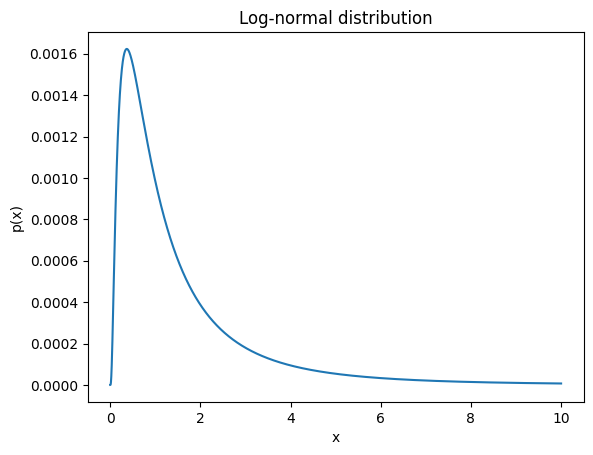

In [2]:
# set up the distribution
# support interval to encode
interval_start = 0
interval_end = 10
# amount of qubits to encode, creates 2^num_qubits grid points
num_qubits = 12
# parameters of the corresponding normal distribution
mu = 0  
sigma = 1

# Scenario 1: standard method
# We consider a method proposed in Qiskit, and available for Financial computations
circuit_qiskit = LogNormalDistribution(num_qubits, mu=mu, sigma=sigma**2, bounds=(interval_start, interval_end))
circuit_qiskit.name = "Qiskit"

# Scenario 2: Haiqu distribution loading
circuit_haiqu = qiskit.QuantumCircuit(num_qubits, name="Haiqu")
distribution_job = haiqu.distribution_loading(distribution_name="lognorm", num_qubits=num_qubits, s=sigma, scale=np.exp(mu),
                                              interval_start=interval_start, interval_end=interval_end)
distribution_gate = distribution_job.result()
circuit_haiqu.compose(distribution_gate, inplace=True)
print(f"Haiqu distribution is loaded with fidelity: {distribution_job.info['fidelity']:.3f}")

# show the distribution we load
plt.plot(circuit_qiskit.values, circuit_qiskit.probabilities)
plt.title("Log-normal distribution")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.show()

Haiqu's distribution loading significantly outperforms standard methods as shown in the comparison table below:

In [3]:
# we consider an ideal device with all-to-all connectivity
device_ideal = haiqu.get_device("aer_simulator")

circuit_qiskit_transpiled = haiqu.transpile(circuit_qiskit, device=device_ideal)

circuit_haiqu_transpiled = haiqu.transpile(circuit_haiqu, device=device_ideal)

haiqu.compare_metrics(circuit_qiskit_transpiled, circuit_haiqu_transpiled)

CIRCUIT,Qiskit-on-aer_simulator,Haiqu-on-aer_simulator
QUBITS,12,12
NUM PARAMETERS,0,0
DEPTH,8167,23
2-Q GATES DEPTH,4083,11
1-Q GATES,4095,53
2-Q GATES,4083,21
OTHER GATES,0,0
GATES TOTAL,8178,74
OTHER OPERATIONS,0,0
INSTRUCTIONS TOTAL,8178,74


## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

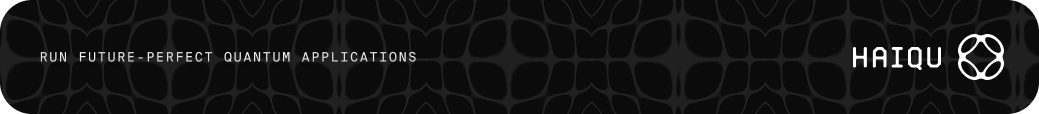